## Cell 1 — Imports


In [1]:
import pandas as pd
import numpy as np
import re

from sklearn.model_selection import train_test_split

pd.set_option("display.max_colwidth", 300)


## Cell 2 — Load dataset


In [2]:
df = pd.read_csv("data/data.csv")

print("Original shape:", df.shape)
display(df.head())


Original shape: (17124, 4)


,Unnamed: 0,text,label,wcount
0,0,‘मोदी के शासन के दौरान गंगा’ गंगा नदी नरेन्द्र मोदी के शाशन में कांग्रेस के मुकाबले काफ़ी स्वच्छ है,1,19
1,1,यह खबर आने से पहले छवि क्रेडिट जस्टिन सुलिवान/गेटी द रियल एजेंडा न्यूज जेम्स ओकीफ के प्रोजेक्ट वेरिटास की जांच के परिणामस्वरूप डीएनसी ओबामा व्हाइट हाउस और हिलेरी क्लिंटन अभियान के बीच भ्रष्टाचार के कभी न खत्म होने वाले स्तर के बारे में अधिक विवरण सामने आए हैं। ट्रम्प की रैलियों में लोगों को बत्त...,1,374
2,2,गुलाब गेंद वाल डे-नाइट टेस्ट मैच कप्ता विराट कोहल टेस्ट मैच के वो भारत लौट क्योंक वो पि बन वाल,0,20
3,3,उत्तर कोरिया रॉकेट प्रक्षेपण योजनाएं 71 0 15 0 0 जापान दक्षिण कोरिया और संयुक्त राज्य अमेरिका के उप विदेश मंत्री उत्तर कोरिया के परमाणु और मिसाइल खतरों के हॉट-बटन मुद्दे पर चर्चा करने के लिए गुरुवार को टोक्यो में त्रिपक्षीय वार्ता करेंगे। मॉस्को स्पुतनिक - वार्ता में अमेरिकी उप विदेश मंत्री एंटन...,1,345
4,4,राष्ट्रपति डोनाल्ड ट्रम्प और प्रथम महिला मेलानिया ट्रम्प ने कांग्रेस के संयुक्त सत्र में अपना पहला संबोधन देखने के लिए एक अवैध आप्रवासी द्वारा ड्यूटी के दौरान मारे गए मारे गए पुलिस अधिकारियों की दो विधवाओं को आमंत्रित किया है। [जेसिका डेविस और सुसान ओलिवर कैलिफोर्निया के जासूस माइकल डेविस और डिप...,0,180


## Cell 3 — Remove unnecessary column


In [3]:
df = df.drop(columns=["Unnamed: 0"], errors="ignore")

print(df.columns)


Index(['text', 'label', 'wcount'], dtype='object')


## Cell 4 — Basic cleaning


In [4]:
def clean_text(text):
    if pd.isna(text):
        return ""

    text = str(text)

    # Remove HTML tags
    text = re.sub(r"<[^>]+>", " ", text)

    # Remove URLs
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text)

    return text.strip()

df["text"] = df["text"].apply(clean_text)


## Cell 5 — Check missing/empty text


In [5]:
print("Missing text:", df["text"].isna().sum())

empty_mask = df["text"].str.strip().eq("")

print("Empty text:", empty_mask.sum())

df = df[~empty_mask].copy()

print("Shape after removing empty text:", df.shape)


Missing text: 0
Empty text: 1
Shape after removing empty text: (17123, 3)


## Cell 6 — Remove exact duplicate texts


In [6]:
before = len(df)

df = df.drop_duplicates(
    subset=["text"],
    keep="first"
).reset_index(drop=True)

after = len(df)

print("Rows before:", before)
print("Rows after:", after)
print("Duplicates removed:", before - after)


Rows before: 17123
Rows after: 16898
Duplicates removed: 225


## Cell 7 — IMPORTANT: conflicting labels


In [7]:
original = pd.read_csv("data/data.csv")

original["text"] = original["text"].apply(clean_text)

conflicting = (
    original.groupby("text")["label"]
    .nunique()
    .reset_index(name="num_labels")
)

conflicting = conflicting[
    conflicting["num_labels"] > 1
]

print("Texts with conflicting labels:", len(conflicting))

conflict_texts = set(conflicting["text"])

display(
    original[
        original["text"].isin(conflict_texts)
    ][["text", "label"]].head(20)
)


Texts with conflicting labels: 8


,text,label
64,अपने ही घर के पिछवाड़े से भागते इस व्यक्ति को पहचानते हैं हिंट एक भाजपा शासित राज्य के मुख्यमंत्री हैं। बूझो तो मानु,0
543,अपने ही घर के पिछवाड़े से भागते इस व्यक्ति को पहचानते हैं हिंट एक भाजपा शासित राज्य के मुख्यमंत्री हैं। बूझो तो मानु,1
8594,कर्नाटक BJP के CM के मंच से ही जब गुरु जी ने CAA का विरोध किया तो CM साहब भड़क उठे ऐसी बे इज्जती आपने कभी नही देखी होगी दलाल मीडिया के चाटूकार पत्रकारो ने एक बार भी नही चलाया करो तो ज़रा फेमस गुरू जी को,1
8666,ये क्या हो गया सच्चा मुसलमान कभी ऐसा नही कर सकता तो इसका मतलब क्या समझा जाये शाहरुख खान सच्चे मुसलमान नही है ओ भी मात्र दो करोड़ रुपये के लिए !,0
8757,पालघर की तर्ज पर पंजाब के होशियार पुर में संत पुष्पेंद्र स्वरूप जी महाराज पर शांतिदूतों ने हमला किया है जब वो घर पर बेटे के साथ थे!! आखिर ये साधु संत की हत्या कांग्रेस शासित राज्यो में ही क्यों हो रही है,1
9414,पालघर की तर्ज पर पंजाब के होशियार पुर में संत पुष्पेंद्र स्वरूप जी महाराज पर शांतिदूतों ने हमला किया है जब वो घर पर बेटे के साथ थे!! आखिर ये साधु संत की हत्या कांग्रेस शासित राज्यो में ही क्यों हो रही है,0
10293,ये क्या हो गया सच्चा मुसलमान कभी ऐसा नही कर सकता तो इसका मतलब क्या समझा जाये शाहरुख खान सच्चे मुसलमान नही है ओ भी मात्र दो करोड़ रुपये के लिए !,1
10861,Bjp विधायक अनिल उपाध्याय की इस बयान पर क्या कहेगे मोदी जी इन video को इतना वायरल करो की ये पूरा हिन्दुस्तान देख सके,0
12024,शाहबाद मारकंडा में नकली EVM मशीने पकड़ी गई दावा है BJP वालों की हरकत,0
12775,भाउ श्री के ब्लेक टिकिट बेचकर खुद बहुत काला पैसे कमाए होओर काले दिन की बात करते शर्म नही साले सांढ़ तू खुद लुटियन मोड़ में है,1


## Cell 8 — Check final label distribution


label
0    9867
1    7031
Name: count, dtype: int64

label
0    58.391526
1    41.608474
Name: proportion, dtype: float64


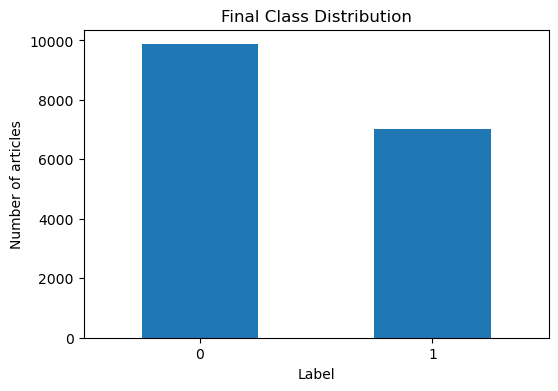

In [8]:
print(df["label"].value_counts())
print()
print(df["label"].value_counts(normalize=True) * 100)

import matplotlib.pyplot as plt

df["label"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(6, 4)
)

plt.xlabel("Label")
plt.ylabel("Number of articles")
plt.title("Final Class Distribution")
plt.xticks(rotation=0)
plt.show()


## Cell 9 — Recalculate word count


In [9]:
df["calculated_word_count"] = (
    df["text"]
    .str.split()
    .str.len()
)

df["wcount_difference"] = (
    df["wcount"] - df["calculated_word_count"]
)

print(
    df["wcount_difference"]
    .describe()
)

mismatch = (
    df["wcount_difference"] != 0
).sum()

print("Word count mismatches:", mismatch)


count    16898.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: wcount_difference, dtype: float64
Word count mismatches: 0


## Cell 10 — Remove obviously unusable text


In [10]:
short_texts = df[
    df["calculated_word_count"] <= 5
]

print("Texts with <=5 words:", len(short_texts))

display(
    short_texts[
        ["text", "label", "calculated_word_count"]
    ].head(50)
)


Texts with <=5 words: 139


,text,label,calculated_word_count
120,वह एक ब्लो-मशाल है!,1,4
250,आहयह अलोहा स्नैक बार है,1,5
317,चीन को तीसरी पटखनी!,0,4
409,एचटीटीपी//वोल्फ्स्ट्रीटकॉम/2016/11/19/बांड-कार्नेज-हिट्स-मॉर्गेज-रेट्स-बूत-थिस-टाइम-इतस-रियल/,1,1
485,टेर्ररिस्ट डोनेशन बाय कांग्रेस,1,4
700,बहुत कमीनी है तेरा पोस्ट,1,5
726,उन्होंने हीटर तेज़ कर दिया।,1,5
752,डम्पट्रम्प और हिलेरी एम,1,4
797,राजने कैस मन रोश पर्व,0,5
871,रोजगार दो जुमला नही ।,0,5


## Cell 11 — Final dataset


In [11]:
final_df = df[
    ["text", "label"]
].copy()

print(final_df.shape)
display(final_df.head())


(16898, 2)


,text,label
0,‘मोदी के शासन के दौरान गंगा’ गंगा नदी नरेन्द्र मोदी के शाशन में कांग्रेस के मुकाबले काफ़ी स्वच्छ है,1
1,यह खबर आने से पहले छवि क्रेडिट जस्टिन सुलिवान/गेटी द रियल एजेंडा न्यूज जेम्स ओकीफ के प्रोजेक्ट वेरिटास की जांच के परिणामस्वरूप डीएनसी ओबामा व्हाइट हाउस और हिलेरी क्लिंटन अभियान के बीच भ्रष्टाचार के कभी न खत्म होने वाले स्तर के बारे में अधिक विवरण सामने आए हैं। ट्रम्प की रैलियों में लोगों को बत्त...,1
2,गुलाब गेंद वाल डे-नाइट टेस्ट मैच कप्ता विराट कोहल टेस्ट मैच के वो भारत लौट क्योंक वो पि बन वाल,0
3,उत्तर कोरिया रॉकेट प्रक्षेपण योजनाएं 71 0 15 0 0 जापान दक्षिण कोरिया और संयुक्त राज्य अमेरिका के उप विदेश मंत्री उत्तर कोरिया के परमाणु और मिसाइल खतरों के हॉट-बटन मुद्दे पर चर्चा करने के लिए गुरुवार को टोक्यो में त्रिपक्षीय वार्ता करेंगे। मॉस्को स्पुतनिक - वार्ता में अमेरिकी उप विदेश मंत्री एंटन...,1
4,राष्ट्रपति डोनाल्ड ट्रम्प और प्रथम महिला मेलानिया ट्रम्प ने कांग्रेस के संयुक्त सत्र में अपना पहला संबोधन देखने के लिए एक अवैध आप्रवासी द्वारा ड्यूटी के दौरान मारे गए मारे गए पुलिस अधिकारियों की दो विधवाओं को आमंत्रित किया है। [जेसिका डेविस और सुसान ओलिवर कैलिफोर्निया के जासूस माइकल डेविस और डिप...,0


## Cell 12 — Train/Validation/Test split


In [12]:
train_df, temp_df = train_test_split(
    final_df,
    test_size=0.30,
    stratify=final_df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)


Train: (11828, 2)
Validation: (2535, 2)
Test: (2535, 2)


## Cell 13 — Verify class distribution


In [13]:
def show_distribution(name, data):
    print(f"\n{name}")
    print("-" * 30)
    print(data["label"].value_counts())
    print()
    print(data["label"].value_counts(normalize=True) * 100)

show_distribution("TRAIN", train_df)
show_distribution("VALIDATION", val_df)
show_distribution("TEST", test_df)



TRAIN
------------------------------
label
0    6907
1    4921
Name: count, dtype: int64

label
0    58.395333
1    41.604667
Name: proportion, dtype: float64

VALIDATION
------------------------------
label
0    1480
1    1055
Name: count, dtype: int64

label
0    58.382643
1    41.617357
Name: proportion, dtype: float64

TEST
------------------------------
label
0    1480
1    1055
Name: count, dtype: int64

label
0    58.382643
1    41.617357
Name: proportion, dtype: float64


## Cell 14 — Check for leakage between splits


In [14]:
train_texts = set(train_df["text"])
val_texts = set(val_df["text"])
test_texts = set(test_df["text"])

print("Train ∩ Validation:", len(train_texts & val_texts))
print("Train ∩ Test:", len(train_texts & test_texts))
print("Validation ∩ Test:", len(val_texts & test_texts))


Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


## Cell 15 — Save the splits


In [15]:
import os

os.makedirs("data/processed", exist_ok=True)

train_df.to_csv(
    "data/processed/train.csv",
    index=False
)

val_df.to_csv(
    "data/processed/validation.csv",
    index=False
)

test_df.to_csv(
    "data/processed/test.csv",
    index=False
)

print("Saved successfully.")


Saved successfully.


## Cell 16 — Final summary


In [16]:
print("=" * 50)
print("FINAL DATASET SUMMARY")
print("=" * 50)

print("Total:", len(final_df))
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

print("\nLabels:")
print(final_df["label"].value_counts())

print("\nTrain labels:")
print(train_df["label"].value_counts())

print("\nValidation labels:")
print(val_df["label"].value_counts())

print("\nTest labels:")
print(test_df["label"].value_counts())


FINAL DATASET SUMMARY
Total: 16898
Train: 11828
Validation: 2535
Test: 2535

Labels:
label
0    9867
1    7031
Name: count, dtype: int64

Train labels:
label
0    6907
1    4921
Name: count, dtype: int64

Validation labels:
label
0    1480
1    1055
Name: count, dtype: int64

Test labels:
label
0    1480
1    1055
Name: count, dtype: int64
